!pip install shap

In [8]:
import sys
!{sys.executable} -m pip install shap


  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.51.0-cp313-cp313-win_amd64.whl (555 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)

   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------------------------------- 3/3 [shap]




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\neilm\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [2]:
model = joblib.load('../models/churn_model.pkl')

df = pd.read_csv('../data/processed_data.csv')

for col in df.columns:
    if str(df[col].dtype) == 'string':
        df[col] = df[col].astype('object')

X = df.drop('Churn', axis=1)
y = df['Churn']

In [5]:
#separate pipeline parts

In [3]:
preprocessor = model.named_steps['preprocessor']
classifier = model.named_steps['classifier']

In [4]:
X_transformed = preprocessor.transform(X)

In [6]:
#get feature names after encoding

In [7]:
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(
    preprocessor.transformers_[1][2]
)

num_feature_names = preprocessor.transformers_[0][2]

feature_names = list(num_feature_names) + list(cat_feature_names)

In [8]:
#convert transformed data if sparse

In [9]:
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

In [11]:
#For logistic regression, LinearExplainer is a good choice:
explainer = shap.LinearExplainer(classifier, X_transformed)
shap_values = explainer.shap_values(X_transformed)

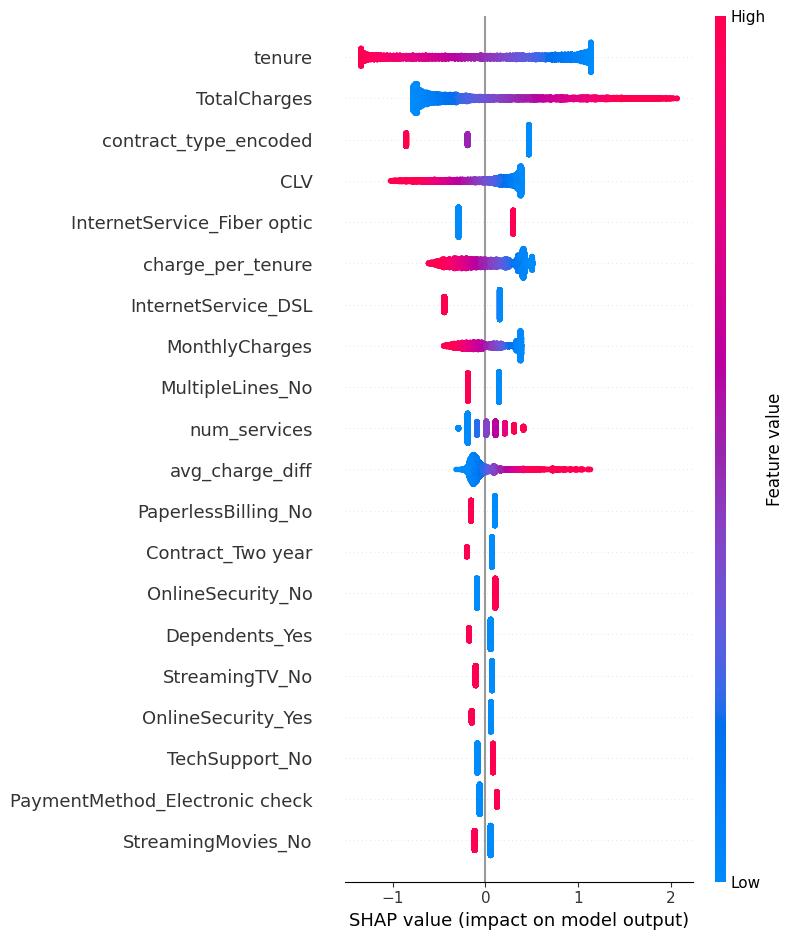

In [12]:
#1. Global explanation:This shows which features matter most overall.
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

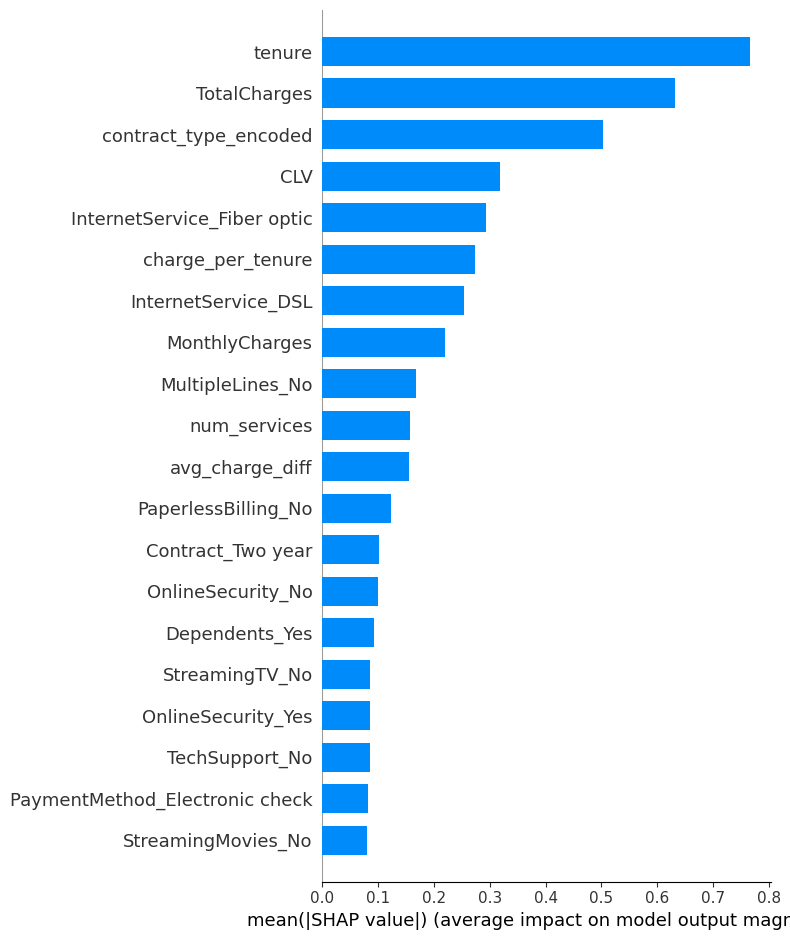

In [13]:
#2. Bar plot of top features
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, plot_type='bar')

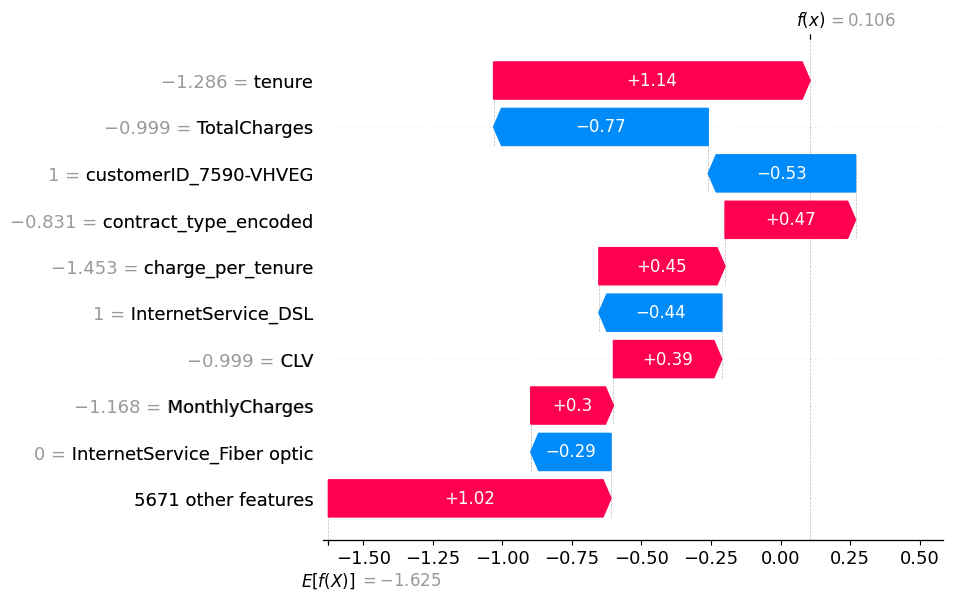

In [14]:
#3. Explain one specific customer Example: first row
customer_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_index],
        base_values=explainer.expected_value,
        data=X_transformed[customer_index],
        feature_names=feature_names
    )
)

#To get top reasons for one customer:
customer_index = 0

customer_shap = pd.DataFrame({
    'feature': feature_names,
    'shap_value': shap_values[customer_index]
})

customer_shap['abs_shap'] = customer_shap['shap_value'].abs()
customer_shap = customer_shap.sort_values('abs_shap', ascending=False)

customer_shap.head(10)

* Positive shap_value means:

* pushes toward churn

* Negative shap_value means:

* pushes toward non-churn

## 1. Global top-feature bar plot

This is the easiest one to present.

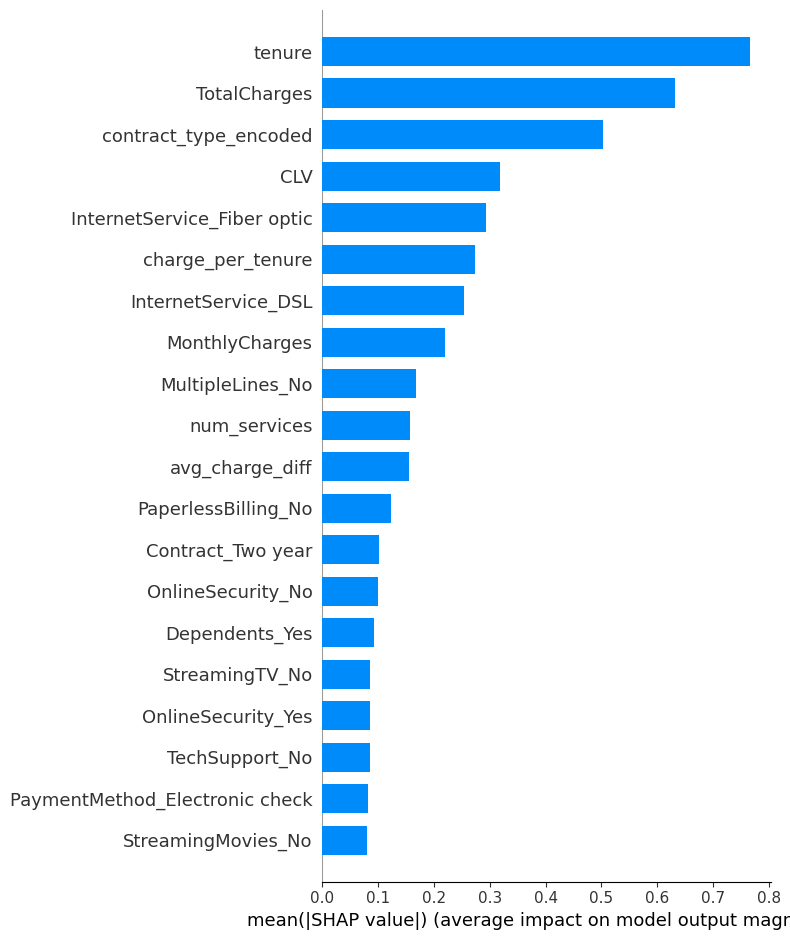

In [18]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type='bar'
)

## 2. SHAP summary plot

This is slightly more advanced and very impressive.

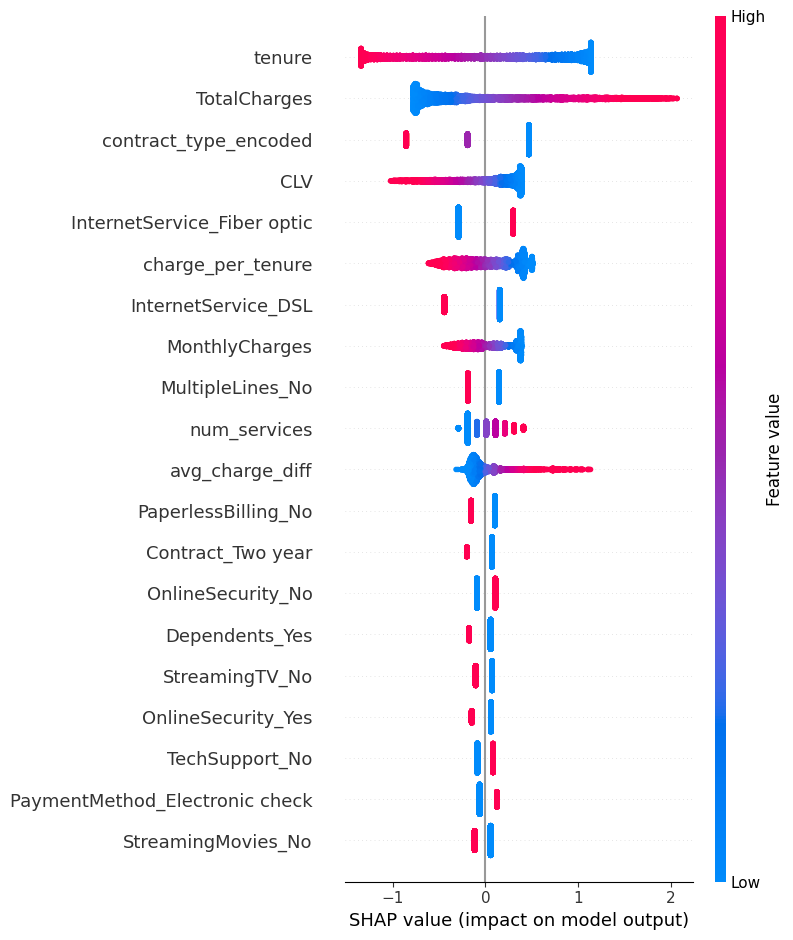

In [19]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names
)

3. One-customer explanation

You already did this part. Keep either:

waterfall plot, or
top reasons table

If the waterfall plot works, keep it.

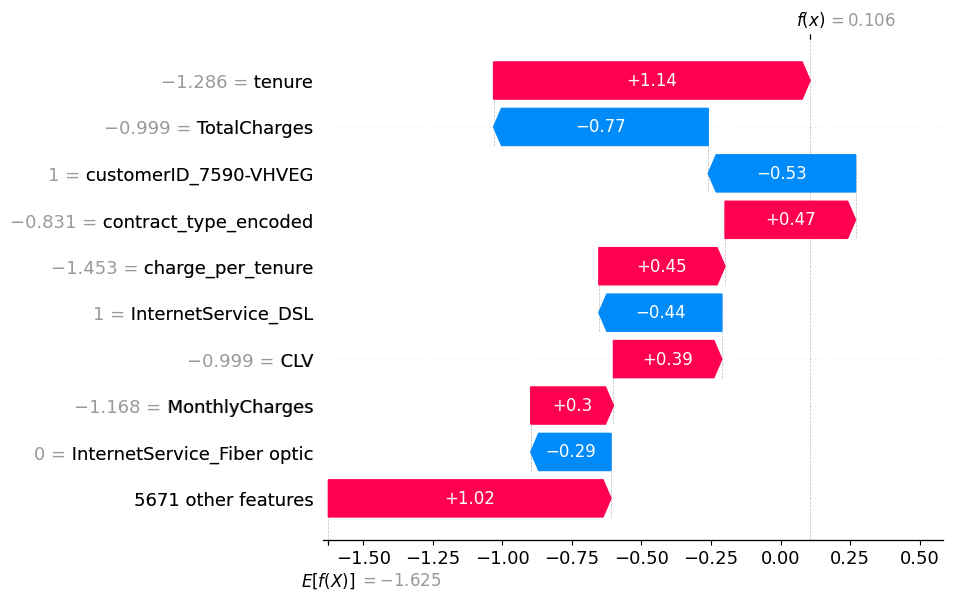

In [20]:
customer_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_index],
        base_values=explainer.expected_value,
        data=X_transformed[customer_index],
        feature_names=feature_names
    )
)

In [21]:
customer_shap.head(10)

,feature,shap_value,abs_shap
1,tenure,1.137650,1.137650
3,TotalCharges,-0.771453,0.771453
4290,customerID_7590-VHVEG,-0.529526,0.529526
8,contract_type_encoded,0.469191,0.469191
4,charge_per_tenure,0.453454,0.453454
5646,InternetService_DSL,-0.442034,0.442034
9,CLV,0.389485,0.389485
2,MonthlyCharges,0.297350,0.297350
5647,InternetService_Fiber optic,-0.288565,0.288565
5,avg_charge_diff,0.221494,0.221494
